# Exp 1: bout-flicker position correspondence

This descriptive all-fish view asks whether the time at which a neuron is recruited during the moving bout corresponds to its response to stationary flicker at the nearest trajectory position. It reuses the Exp 1 loader and the Cell 06 significant-raster activity decision.

The trajectory CSVs are the spatial source of truth. The matched position indices printed below are zero-based trajectory-visit indices.

In [26]:
# Cell 01 - Setup
from importlib import reload
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.multifish_analysis as mfa
import src.plotting as plott
import src.reusable_several_fish as rsf

mfa, plott, rsf = reload(mfa), reload(plott), reload(rsf)


In [27]:
# Cell 02 - User settings
USER_SETTINGS = {
    'experiment_name': 'Exp_1_flickering',
    'data_base': Path(r'D:\Alejandro\Data'),
    # Maintained Exp 1 cohort from 01_all_fish_raster.ipynb.
    'fish_ids': ['L433_f02', 'L433_f04', 'L453_f09', 'L453_f11', 'L453_f08'],
    'selected_blocks': ['B1', 'B2'],
    'verbose_loading': False,
    'timing': {'fps_2p': 2.0, 't_pre_s': 5.0, 't_post_s': 32.0},
    'stim_order': [1, 2, 3, 4, 5, 6, 7, 8],
}

BOUT_FLICKER_SETTINGS = {
    'side_conditions': {
        'left': {'bout': 'FLB', 'flickers': ['FL1', 'FL2', 'FL3']},
        'right': {'bout': 'FRB', 'flickers': ['FR1', 'FR2', 'FR3']},
    },
    # The trajectory reader fails clearly if this needs to be specified.
    'coordinate_dot_prefix': None,
    'matching_method': 'euclidean',
    # Match the Cell 06 epoch rule: two consecutive 2 Hz imaging frames (1 s).
    'onset_persistence_frames': 2,
    # Match Cell 06's two-of-four-repetition rule (not a new threshold).
    'onset_min_significant_trial_fraction': 0.50,
    # Keep only neurons active in the bout control and at least one same-side flicker.
    'require_bout_and_flicker_active': True,
    # Half an imaging frame: match a strict onset to the nearest bout-position time.
    'onset_match_tolerance_s': 0.25,
    # These are the Cell 06 active-neuron decision settings, exposed unchanged.
    'active_fraction_threshold': 0.10,
    'min_epoch_s': 1.0,
    'min_active_reps': 2,
    'expected_reps': 4,
    'require_expected_reps': True,
    'motion_onset_s': 8.0,
    'tau_s': 6.0,
    # Relative to the matched bout time and to flicker onset, respectively.
    'position_window_offsets_s': (-1.0, 2.0),
    'flicker_window_offsets_s': (0.0, 3.0),
    'save_figures': False,
    'figure_dirname': '02_bout_flicker_position_onset',
}


In [28]:
# Cell 03 - Load the same aligned z-score and significant-raster inputs as Cell 06.
raster_inputs = rsf.load_and_preflight_fish_raster_inputs(USER_SETTINGS)
globals().update(raster_inputs)
stimuli_path = analysis_path / USER_SETTINGS['experiment_name'] / 'stimuli'
print('Detected stimulus map:', stimuli_id_map)
print('Trajectory metadata folder:', stimuli_path)


Detected stimulus map: {'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}
Trajectory metadata folder: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis\Exp_1_flickering\stimuli


In [29]:
# Cell 04 - Derive spatial matches, Cell-06 active decisions, and one order per hemifield.
# This must run before the plotting cell so the metadata validation table is visible first.
position_result = mfa.build_bout_flicker_position_analysis(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    side_conditions=BOUT_FLICKER_SETTINGS['side_conditions'],
    stimuli_path=stimuli_path,
    fps_2p=timing['fps_2p'],
    t_pre_s=timing['t_pre_s'],
    active_fraction_threshold=BOUT_FLICKER_SETTINGS['active_fraction_threshold'],
    min_epoch_s=BOUT_FLICKER_SETTINGS['min_epoch_s'],
    min_active_reps=BOUT_FLICKER_SETTINGS['min_active_reps'],
    expected_reps=BOUT_FLICKER_SETTINGS['expected_reps'],
    require_expected_reps=BOUT_FLICKER_SETTINGS['require_expected_reps'],
    motion_onset_s=BOUT_FLICKER_SETTINGS['motion_onset_s'],
    tau_s=BOUT_FLICKER_SETTINGS['tau_s'],
    onset_persistence_frames=BOUT_FLICKER_SETTINGS['onset_persistence_frames'],
    onset_min_significant_trial_fraction=BOUT_FLICKER_SETTINGS['onset_min_significant_trial_fraction'],
    require_bout_and_flicker_active=BOUT_FLICKER_SETTINGS['require_bout_and_flicker_active'],
    matching_method=BOUT_FLICKER_SETTINGS['matching_method'],
    coordinate_dot_prefix=BOUT_FLICKER_SETTINGS['coordinate_dot_prefix'],
    position_window_offsets_s=BOUT_FLICKER_SETTINGS['position_window_offsets_s'],
    flicker_window_offsets_s=BOUT_FLICKER_SETTINGS['flicker_window_offsets_s'],
)

match_validation = position_result['position_metadata']['validation_table']
display(match_validation)
print('nearest_bout_position_index is zero-based and follows visible bout trajectory order.')
for side, side_result in position_result['sides'].items():
    print(f"{side}: {len(side_result['order_table'])} union neurons; "
          f"{side_result['n_bout_active']} bout-active, then flicker-only.")


,hemifield,flicker_stimulus,flicker_x,flicker_y,nearest_bout_position_index,nearest_bout_x,nearest_bout_y,spatial_matching_error,time_after_motion_onset_s
0,left,FL1,-1.795650,-0.125060,1,-1.795,-0.125,0.000653,0.6
1,left,FL2,-1.338669,-1.203314,5,-1.339,-1.203,0.000456,3.0
2,left,FL3,-0.315041,-1.772216,9,-0.315,-1.772,0.000220,5.4
3,right,FR1,0.125060,1.795650,1,0.125,1.795,0.000653,0.6
4,right,FR2,1.203314,1.338669,5,1.203,1.339,0.000456,3.0
5,right,FR3,1.772216,0.315041,9,1.772,0.315,0.000220,5.4


nearest_bout_position_index is zero-based and follows visible bout trajectory order.
left: 880 union neurons; 880 bout-active, then flicker-only.
right: 964 union neurons; 964 bout-active, then flicker-only.


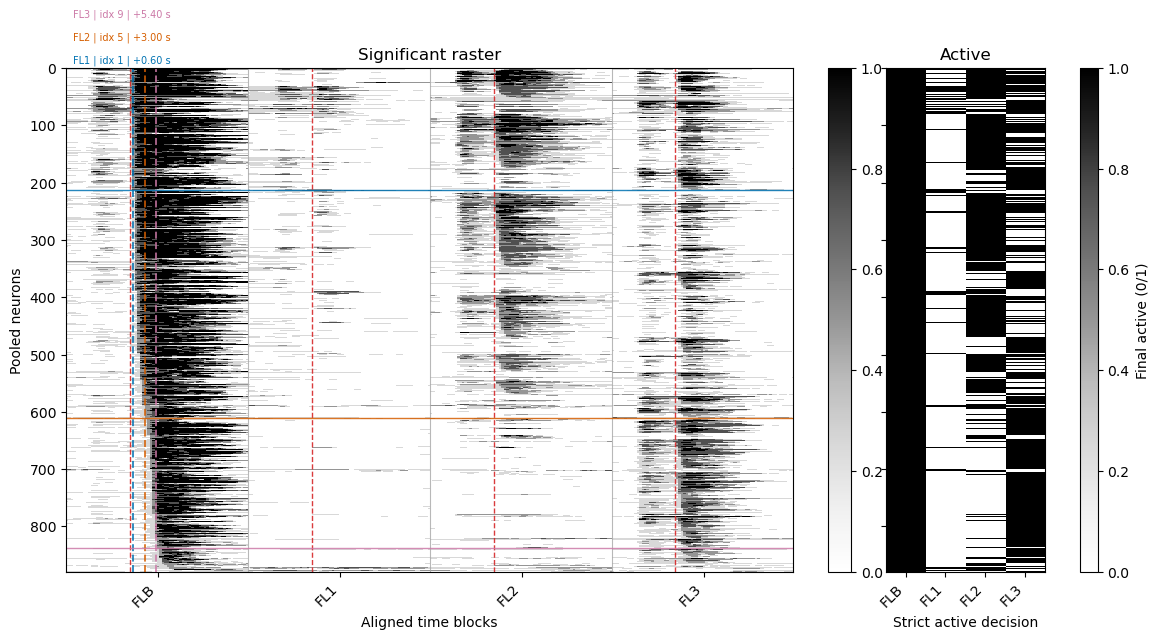

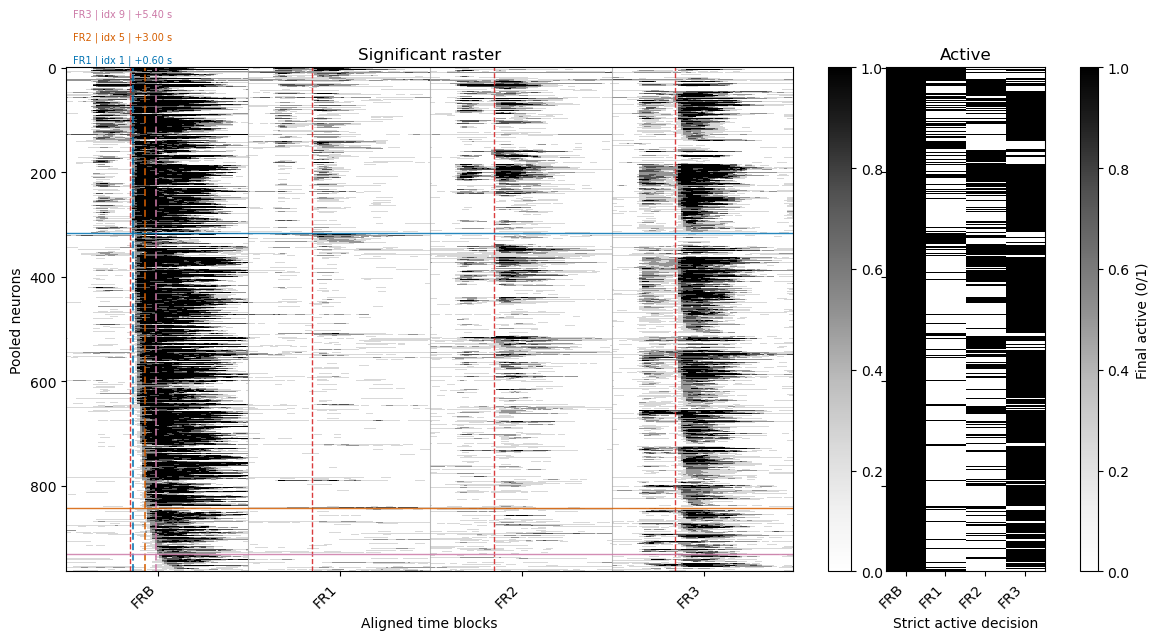

In [30]:
# Cell 05 - Cell 06 significant raster: bout-and-flicker neurons, ordered by strict bout onset.
figures = {
    side: plott.plot_bout_flicker_position_cell06_style(
        side_result, fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
        onset_match_tolerance_s=BOUT_FLICKER_SETTINGS['onset_match_tolerance_s'],
    )
    for side, side_result in position_result['sides'].items()
}

for side, figure_result in figures.items():
    display(figure_result['figure'])
    if BOUT_FLICKER_SETTINGS['save_figures']:
        figure_dir = analysis_path / USER_SETTINGS['experiment_name'] / BOUT_FLICKER_SETTINGS['figure_dirname']
        figure_dir.mkdir(parents=True, exist_ok=True)
        figure_path = figure_dir / f"{side}_bout_flicker_position_onset.png"
        if figure_path.exists():
            raise FileExistsError(f"Refusing to overwrite existing figure: {figure_path}")
        figure_result['figure'].savefig(figure_path, dpi=220, bbox_inches='tight')
        print('Saved:', figure_path)
    plt.close(figure_result['figure'])


## Interpretation limit

This visualization does not isolate spatial position. During FLB/FRB, the time a dot reaches a position is confounded with elapsed time after motion onset, preceding trajectory history, accumulated displacement, adaptation, and calcium-response delay/kinetics. It can reveal correspondence between bout recruitment timing and stationary-flicker responses, but cannot independently establish retinotopic or position-selective coding.